# Name classification using a character-level RNN

We will build and train a simple character-level recurrent neural network (RNN) for word classification. The model processes words one character at a time, updating its hidden state at each step and using the final output to predict the word’s class.

In this example, the RNN is trained on thousands of surnames from 18 languages and learns to predict the language of origin based on spelling patterns.


# Data Preparation

Download the names.zip data and unzip it to the directory.

In [9]:
!mkdir -p downloads/names

In [10]:
!unzip data/names.zip -d downloads/names

Archive:  data/names.zip
   creating: downloads/names/data
  inflating: downloads/names/data/eng-fra.txt  
   creating: downloads/names/data/names
  inflating: downloads/names/data/names/Arabic.txt  
  inflating: downloads/names/data/names/Chinese.txt  
  inflating: downloads/names/data/names/Czech.txt  
  inflating: downloads/names/data/names/Dutch.txt  
  inflating: downloads/names/data/names/English.txt  
  inflating: downloads/names/data/names/French.txt  
  inflating: downloads/names/data/names/German.txt  
  inflating: downloads/names/data/names/Greek.txt  
  inflating: downloads/names/data/names/Irish.txt  
  inflating: downloads/names/data/names/Italian.txt  
  inflating: downloads/names/data/names/Japanese.txt  
  inflating: downloads/names/data/names/Korean.txt  
  inflating: downloads/names/data/names/Polish.txt  
  inflating: downloads/names/data/names/Portuguese.txt  
  inflating: downloads/names/data/names/Russian.txt  
  inflating: downloads/names/data/names/Scottish.txt

The `data/names` directory contains 18 text files named `[Language].txt`, each with one surname per line. Most names are romanized, but they still need to be converted from Unicode to ASCII.

Converting Unicode names to ASCII helps standardize the dataset by removing diacritics and special characters, making text processing and model training more consistent.

After preprocessing, the data will be stored as a dictionary in the form `{language: [names ...]}`. The variables `category` and `line` (language and name) are used for consistency and extensibility.


In [11]:
from io import open
import glob
import os

# Finds all files at the specified path
def findFiles(path): return glob.glob(path)

print(findFiles('downloads/names/data/names/*.txt'))

import unicodedata
import string

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

# Converts a Unicode string to plain ASCII, thanks https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

print(unicodeToAscii('Ślusàrski'))

['downloads/names/data/names/Czech.txt', 'downloads/names/data/names/German.txt', 'downloads/names/data/names/Arabic.txt', 'downloads/names/data/names/Japanese.txt', 'downloads/names/data/names/Chinese.txt', 'downloads/names/data/names/Vietnamese.txt', 'downloads/names/data/names/Russian.txt', 'downloads/names/data/names/French.txt', 'downloads/names/data/names/Irish.txt', 'downloads/names/data/names/English.txt', 'downloads/names/data/names/Spanish.txt', 'downloads/names/data/names/Greek.txt', 'downloads/names/data/names/Italian.txt', 'downloads/names/data/names/Portuguese.txt', 'downloads/names/data/names/Scottish.txt', 'downloads/names/data/names/Dutch.txt', 'downloads/names/data/names/Korean.txt', 'downloads/names/data/names/Polish.txt']
Slusarski


In [12]:
# Create a dictionary category_lines, a list of names for each language
category_lines = {}
all_categories = []

# Reads a file and splits it into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

# go through each file in the specified directory
for filename in findFiles('downloads/names/data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]  # get category name from the file name
    all_categories.append(category)  # Add a category to the list of all categories
    lines = readLines(filename)  # Read all lines from the file
    category_lines[category] = lines  # Add a list of names to the dictionary by category

n_categories = len(all_categories)  # Determine the number of categories

We now have `category_lines`, a dictionary that maps each category (language) to a list of lines (names). We also created `all_categories` (just a list of languages) and `n_categories` for later use.

In [13]:
print(category_lines['Italian'][:5])

['Abandonato', 'Abatangelo', 'Abatantuono', 'Abate', 'Abategiovanni']


In [14]:
print(category_lines['Polish'][:5])

['Adamczak', 'Adamczyk', 'Andrysiak', 'Auttenberg', 'Bartosz']


In [15]:
sum(len(v) for v in category_lines.values())

20074

20k names in total

In [16]:
{k: len(v) for k,v in category_lines.items()}

{'Czech': 519,
 'German': 724,
 'Arabic': 2000,
 'Japanese': 991,
 'Chinese': 268,
 'Vietnamese': 73,
 'Russian': 9408,
 'French': 277,
 'Irish': 232,
 'English': 3668,
 'Spanish': 298,
 'Greek': 203,
 'Italian': 709,
 'Portuguese': 74,
 'Scottish': 100,
 'Dutch': 297,
 'Korean': 94,
 'Polish': 139}

high imbalance in dataset

# Converting Names to Tensors

To use names in the neural network, they must first be converted into tensors.

Each letter is represented as a one-hot vector of size `<1 x n_letters>`, containing all zeros except for a single `1` at the position of the current character (e.g. `"b" = <0 1 0 0 ...>`).

A full name is then represented as a sequence of these vectors, forming a tensor of shape `<line_length x 1 x n_letters>`.

The extra dimension is included because PyTorch expects data to be processed in batches. In this case, we use a batch size of 1.


In [18]:
len(all_letters)

57

In [19]:
all_letters.find('J')

35

In [20]:
import torch

# Find the index of the letter from all_letters, for example, "a" = 0
def letterToIndex(letter):
    return all_letters.find(letter)

# For demonstration: convert a letter into a tensor of size <1 x n_letters>
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

# Convert the string to a tensor of size <line_length x 1 x n_letters>,
# or an array of vectors representing the letters in one-hot encoding
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

print(letterToTensor('J'))

print(lineToTensor('Jones').size())

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
torch.Size([5, 1, 57])


In [21]:
lineToTensor('Jones')

tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0

# Creating a Network

The following RNN class implements a "vanilla RNN" and consists of just 3 linear layers,
which operate on the input data and the hidden state, with a `LogSoftmax` layer after the output.

In [22]:
import torch.nn as nn
import torch.nn.functional as F

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size

        self.W_xh = nn.Linear(input_size, hidden_size)
        self.W_hh = nn.Linear(hidden_size, hidden_size)
        self.W_hy = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        hidden = F.tanh(self.W_xh(input) + self.W_hh(hidden))
        output = self.W_hy(hidden)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

n_hidden = 128
rnn = RNN(n_letters, n_hidden, n_categories)

In [23]:
rnn

RNN(
  (W_xh): Linear(in_features=57, out_features=128, bias=True)
  (W_hh): Linear(in_features=128, out_features=128, bias=True)
  (W_hy): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)

To run one step of the network, we pass the input tensor for the current letter together with the previous hidden state (initialized with zeros at the start). The network returns the output probabilities for each language and the updated hidden state, which is used in the next step.


In [32]:
input = letterToTensor('A')
hidden = torch.zeros(1, n_hidden)

output, next_hidden = rnn(input, hidden)
output

tensor([[-2.7598, -2.9191, -2.9419, -2.7814, -2.9277, -2.9867, -2.8003, -2.9259,
         -2.9282, -2.8534, -2.9206, -2.9870, -2.9258, -3.1228, -2.7774, -2.8380,
         -2.9780, -2.7357]], grad_fn=<LogSoftmaxBackward0>)

In [33]:
hidden

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.]])

In [34]:
torch.exp(output)

tensor([[0.0633, 0.0540, 0.0528, 0.0620, 0.0535, 0.0505, 0.0608, 0.0536, 0.0535,
         0.0576, 0.0539, 0.0504, 0.0536, 0.0440, 0.0622, 0.0585, 0.0509, 0.0648]],
       grad_fn=<ExpBackward0>)

For efficiency, we don't want to create a new tensor from a letter for each step, so we will use `lineToTensor` instead of `letterToTensor` and use slices. This can be further optimized by precomputing batches of tensors.

In [35]:
input.shape

torch.Size([1, 57])

In [36]:
input = lineToTensor('Albert')
hidden = torch.zeros(1, n_hidden)

output, next_hidden = rnn(input[0], hidden) # виклик знову ж тільки на одній літері
output, next_hidden = rnn(input[1], next_hidden)
output, next_hidden = rnn(input[2], next_hidden)
output, next_hidden = rnn(input[3], next_hidden)
output, next_hidden = rnn(input[4], next_hidden)
output, next_hidden = rnn(input[5], next_hidden)
print(output)

tensor([[-2.8420, -2.9151, -2.8490, -2.8184, -2.8750, -2.9887, -2.7426, -2.8120,
         -2.8785, -2.9697, -2.9152, -2.8851, -2.8803, -3.0208, -2.9827, -2.9053,
         -2.9643, -2.8271]], grad_fn=<LogSoftmaxBackward0>)


In [37]:
torch.exp(output)

tensor([[0.0583, 0.0542, 0.0579, 0.0597, 0.0564, 0.0504, 0.0644, 0.0601, 0.0562,
         0.0513, 0.0542, 0.0558, 0.0561, 0.0488, 0.0507, 0.0547, 0.0516, 0.0592]],
       grad_fn=<ExpBackward0>)

In [38]:
input.shape

torch.Size([6, 1, 57])

As you can see, the output is a tensor `<1 x n_categories>`, where each element is the probability of that category (higher probability means more likely).

# Training

## Preparing for Training

Before training, we create a few helper functions. The first function interprets the network output, which represents the probability for each category. We use `Tensor.topk` to get the index of the highest probability.


In [39]:
all_categories[10]

'Spanish'

In [40]:
def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i

print(categoryFromOutput(output))

('Russian', 6)


We also want a quick way to get an example from the training dataset (name and its language):

In [41]:
import random

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def randomTrainingExample():
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor

for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    print('category =', category, '/ line =', line)

category = Dutch / line = Baarle
category = Japanese / line = Morishita
category = Japanese / line = Ayugai
category = English / line = Sunderland
category = Russian / line = Ebers
category = Portuguese / line = Rocha
category = French / line = Victor
category = Korean / line = Ryu
category = Dutch / line = Reynder
category = English / line = Roach


# Training the Network

Now we only need to show the network examples, let it make predictions, and update it when it is wrong.

## Softmax vs Log Softmax

**Softmax** and **log softmax** convert raw model outputs (logits) into probabilities or log-probabilities for classification tasks.

### 1. Softmax

Softmax turns logits into probabilities that sum to 1, making outputs interpretable as class probabilities.

* **Formula**:
  $$
  \text{softmax}(x_i) = \frac{\exp(x_i)}{\sum_{j} \exp(x_j)}
  $$

* **Idea**:
  Maps arbitrary real values into a probability distribution over classes.

### 2. Log Softmax

Log softmax computes the logarithm of softmax probabilities in a numerically stable way.

* **Formula**:
  $$
  \text{log softmax}(x_i) = x_i - \log\left(\sum_{j} \exp(x_j)\right)
  $$

* **Idea**:
  Produces log-probabilities directly, avoiding separate softmax + log steps.

## Why use Log Softmax instead of Softmax

* **Numerical stability** — avoids overflow/underflow from exponentials
* **Efficiency** — combines softmax and log into one operation
* **Loss compatibility** — works directly with negative log-likelihood loss

## Example

* **Softmax**: logits `[2.0, 1.0, 0.1]` → probabilities `[0.65, 0.24, 0.11]`
* **Log softmax**: `[−0.43, −1.43, −2.33]` (log-probabilities)

## LogSoftmax + NLLLoss

* `nn.LogSoftmax` outputs log-probabilities instead of probabilities
* `nn.NLLLoss` expects log-probabilities and computes loss for the correct class
* Together they form a stable and standard setup for multi-class classification


# NLLLoss vs CrossEntropyLoss

The main difference between **NLLLoss** and **CrossEntropyLoss** is whether softmax (or log softmax) must be applied manually.

## 1. NLLLoss (Negative Log Likelihood Loss)

* **Formula**:
  $$
  \text{NLLLoss} = -\log(p(y))
  $$

* **Idea**:
  Measures the negative log-probability of the correct class.

* **Input requirement**:
  Expects **log-probabilities**, usually produced by `LogSoftmax`.

* **Usage**:
  Use when your model already outputs log-probabilities.

## 2. CrossEntropyLoss

* **Formula**:
  $$
  \text{CrossEntropyLoss} = -\log\left(\frac{\exp(x_y)}{\sum_j \exp(x_j)}\right)
  $$

* **Idea**:
  Combines softmax + log likelihood in a single step.

* **Input requirement**:
  Takes **raw logits** (no softmax needed).

* **Usage**:
  Most common choice because it is simpler and more convenient.

## Key difference

* **NLLLoss** → requires `LogSoftmax` output
* **CrossEntropyLoss** → applies softmax internally

## Summary

* NLLLoss works with log-probabilities (manual `LogSoftmax` required)
* CrossEntropyLoss works directly with logits (softmax included internally)
* CrossEntropyLoss is more commonly used due to simplicity


In [42]:
import torch
import torch.nn as nn

# Examples for CrossEntropyLoss
logits = torch.tensor([[1.0, 2.0, 3.0], [1.0, 2.0, 3.0]])  # raw logits
targets = torch.tensor([2, 1])  # correct class indeces

cross_entropy_loss = nn.CrossEntropyLoss()
loss_ce = cross_entropy_loss(logits, targets)

# Examples for NLLLoss
log_probs = torch.nn.functional.log_softmax(logits, dim=1)  # use log softmax
nll_loss = nn.NLLLoss()
loss_nll = nll_loss(log_probs, targets)

print(loss_ce, loss_nll)

tensor(0.9076) tensor(0.9076)


In [43]:
criterion = nn.NLLLoss()

Each training epoch will:

- Create input and target tensors
- Create a zero initial hidden state
- Read each letter and
- Store the hidden state for the next letter
- Compare the final output with the target
- Perform back-propagation
- Return the output and loss

In [44]:
learning_rate = 0.005 # If you set it too high, the gradients may start to blow up. If it is too low, the model may not learn.

def train(rnn, category_tensor, line_tensor):
    """
    Processing a single instance of data.
    """
    hidden = rnn.initHidden()

    rnn.zero_grad()

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    # Compare the predicted category obtained after processing the entire sequence
    # with the true value
    loss = criterion(output, category_tensor)
    loss.backward()

    # Add the parameter gradients to their values ​​multiplied by the learning rate
    for p in rnn.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)

    return output, loss.item()

Now we just need to run this with a lot of examples. Since the `train` function returns both the output and the loss, we can output the predictions and also track the loss to plot. Since we have thousands of examples, we just output every `print_every` example and take the average of the losses.

In [45]:
import time
import math

n_iters = 100000
print_every = 5000
plot_every = 1000


# Collect loses for the graph
current_loss = 0
all_losses = []

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

start = time.time()

for iter in range(1, n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output, loss = train(rnn, category_tensor, line_tensor)
    current_loss += loss

    # Print the iteration number ``iter``, loss, name and language prediction
    if iter % print_every == 0:
        guess, guess_i = categoryFromOutput(output)
        correct = '✓' if guess == category else '✗ (%s)' % category
        print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))

    # Add the current average loss to the loss tracking list
    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0

5000 5% (0m 2s) 3.2367 Ii / Korean ✗ (Japanese)
10000 10% (0m 4s) 2.0506 Millar / French ✗ (Scottish)
15000 15% (0m 5s) 0.2347 Paitakes / Greek ✓
20000 20% (0m 7s) 0.5718 Hantimerov / Russian ✓
25000 25% (0m 9s) 0.3740 Bassani / Italian ✓
30000 30% (0m 11s) 2.7609 Lama / Japanese ✗ (Italian)
35000 35% (0m 13s) 2.8269 Meadhra / Czech ✗ (Irish)
40000 40% (0m 15s) 0.8433 Yeo / Chinese ✗ (Korean)
45000 45% (0m 17s) 1.0871 Peatain / Irish ✓
50000 50% (0m 18s) 0.0045 Vamvakidis / Greek ✓
55000 55% (0m 20s) 1.0478 Macleod / Scottish ✓
60000 60% (0m 22s) 0.2775 Dubrov / Russian ✓
65000 65% (0m 24s) 0.3867 Belrose / French ✓
70000 70% (0m 26s) 0.2056 Ortega / Spanish ✓
75000 75% (0m 28s) 0.0460 Mcmillan / Scottish ✓
80000 80% (0m 29s) 5.0039 Ivor / French ✗ (Irish)
85000 85% (0m 31s) 0.8149 Docherty / Scottish ✓
90000 90% (0m 33s) 0.0609 Close / Greek ✓
95000 95% (0m 35s) 1.6706 Blanco / Italian ✗ (Spanish)
100000 100% (0m 37s) 1.4441 Vaca / Czech ✓


# Results graphs

The historical loss graph with `all_losses` shows how the network
learns:

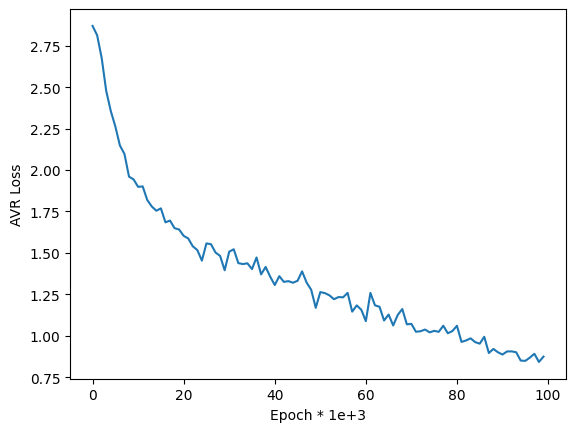

In [47]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.xlabel('Epoch * 1e+3')
plt.ylabel('AVR Loss')
plt.plot(all_losses);

# Evaluating Results

To see how well the network performs with different categories, we will create a confusion matrix that indicates for each actual language (rows) which language the network guesses (columns). To calculate the confusion matrix, several samples are passed through the network using `evaluate()`, which is the same as `train()`, except for the backpropagation.

In [53]:
# Simply returns the result for the passed sequence
def evaluate(line_tensor, rnn):
    hidden = rnn.initHidden()

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    return output

def plot_confusion(rnn):
  # Tracking correct guesses in the confusion matrix
  confusion = torch.zeros(n_categories, n_categories)
  n_confusion = 10000

  # Going through lots of examples and recording correct guesses
  for i in range(n_confusion):
      category, line, category_tensor, line_tensor = randomTrainingExample()
      output = evaluate(line_tensor, rnn)
      guess, guess_i = categoryFromOutput(output)
      category_i = all_categories.index(category)
      confusion[category_i][guess_i] += 1

  # Normalization by dividing each row by its sum
  for i in range(n_categories):
      confusion[i] = confusion[i] / confusion[i].sum()

  # plot setup
  fig = plt.figure(figsize=(8, 8))
  ax = fig.add_subplot(111)
  cax = ax.matshow(confusion.numpy())
  fig.colorbar(cax)

  # axes setup
  ax.set_xticklabels([''] + all_categories, rotation=90)
  ax.set_yticklabels([''] + all_categories)

  # Setting a signature on each label
  ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
  ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

  # sphinx_gallery_thumbnail_number = 2
  plt.show()

/var/folders/0s/q_d47bvj0hq4rs_6q_06d63m0000gn/T/ipykernel_47983/1424019343.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/var/folders/0s/q_d47bvj0hq4rs_6q_06d63m0000gn/T/ipykernel_47983/1424019343.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


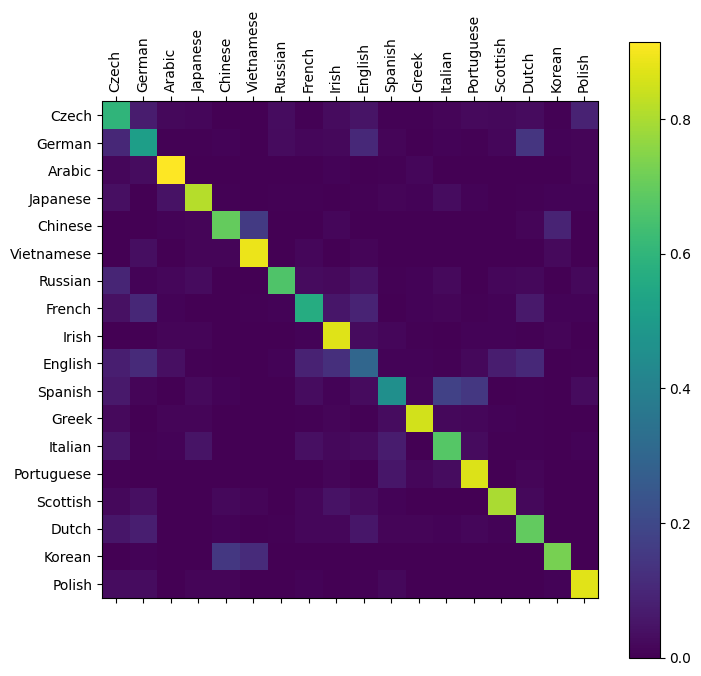

In [54]:
plot_confusion(rnn)

You can see bright off-diagonal spots indicating common misclassifications, such as Chinese being confused with Korean and Spanish with Italian. The model performs very well on Greek, but relatively poorly on English, possibly due to overlap with other languages.

# Run based on user input

In [57]:
def predict(input_line, n_predictions=3):
    print('\n> %s' % input_line)
    with torch.no_grad():
        output = evaluate(lineToTensor(input_line), rnn)

        # get top N categories
        topv, topi = output.topk(n_predictions, 1, True)
        predictions = []

        for i in range(n_predictions):
            value = topv[0][i].item()
            category_index = topi[0][i].item()
            print('(%.2f) %s' % (value, all_categories[category_index]))
            predictions.append([value, all_categories[category_index]])

In [81]:
predict('Stefanko')
predict('Jackson')
predict('Trump')
predict('Macron')
predict('Mamamia')


> Stefanko
(-0.61) Polish
(-1.07) Czech
(-2.54) Russian

> Jackson
(-0.13) Scottish
(-2.27) English
(-5.00) French

> Trump
(-0.17) German
(-3.21) English
(-3.25) French

> Macron
(-1.20) French
(-1.41) Irish
(-1.52) English

> Mamamia
(-0.87) Italian
(-1.37) Arabic
(-2.13) Japanese


In [67]:
predict('McManaman')
predict('London')
predict('Johnson')
predict('Gudjohnsen')
predict('Pedritto')


> McManaman
(-0.69) Arabic
(-1.88) English
(-2.20) Irish

> London
(-0.68) English
(-1.34) French
(-1.85) Irish

> Johnson
(-0.34) Scottish
(-1.93) English
(-2.72) Russian

> Gudjohnsen
(-0.82) English
(-1.48) Russian
(-2.07) Scottish

> Pedritto
(-0.87) Portuguese
(-1.02) Italian
(-1.81) Spanish


In [76]:
predict('Lee')
predict('Hui')
predict('Suzuki')
predict('Son')
predict('Salah')


> Lee
(-0.57) Chinese
(-1.73) Korean
(-2.13) Vietnamese

> Hui
(-0.27) Chinese
(-1.59) Vietnamese
(-3.38) Korean

> Suzuki
(-0.03) Japanese
(-3.70) Polish
(-5.43) Czech

> Son
(-0.05) Korean
(-3.23) Chinese
(-5.74) Scottish

> Salah
(-0.44) Polish
(-1.96) Czech
(-2.00) Arabic


In [79]:
predict('Ramos')
predict('Platon')
predict('Ptolemaeus')
predict('Papadopoulos')
predict('Brzeczyszczykiewicz')


> Ramos
(-0.41) Portuguese
(-1.78) Spanish
(-2.82) Arabic

> Platon
(-0.95) Spanish
(-1.45) Czech
(-1.98) English

> Ptolemaeus
(-0.91) Portuguese
(-1.64) Czech
(-2.13) Spanish

> Papadopoulos
(-0.01) Greek
(-5.58) Spanish
(-7.24) Polish

> Brzeczyszczykiewicz
(-0.21) Polish
(-2.73) Russian
(-3.47) English
